## Example of 1-Dimensional Combination with Parameters for Unknown Systematics

#### Packages, datafiles, KDEs

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d
from scipy.special import logsumexp

# constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
c = 2.99792458e8      # m s^-1
M_sun = 1.98847e30    # kg
floor = 1e-300         # floor for log calculations

# input models with M--R data
MODELS = {
    "ST_PST19": dict(file="../datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="../datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra24: ST+PDT"),
    "ST_PST":   dict(file="../datafiles/ST_PST",   color="tab:orange", label="Vinciguerra24: ST+PST"),
    "PDT_U":    dict(file="../datafiles/PDT_U",    color="tab:green",  label="Vinciguerra24: PDT--U"),
    "ST_U":     dict(file="../datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra24: ST--U"),
    "2spot":    dict(file="../datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="../datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
    "PDT_U26": dict(file="../datafiles/PDT_U26",  color="tab:olive",  label="Kini26: PDT--U"),
}

# load data and compute compactness
KDEs_1D = {}
C_med = {}
C_lo = {}
C_hi = {}
S_i = {}
for key, meta in MODELS.items():
    filename = meta["file"]

    data = np.loadtxt(filename)
    M, R = data.T[0], data.T[1]

    # Unit conversions
    M_si = M * M_sun     # solar masses → kg
    R_si = R * 1e3       # km → m

    # Compactness C = GM / (Rc^2)
    C = G * M_si / (R_si * c**2)

    # Summary statistics
    C_med[key] = np.median(C)
    C_lo[key] = np.min(C)
    C_hi[key] = np.max(C)
    S_i[key] = max(C_hi[key]- C_med[key], C_med[key]- C_lo[key])
    C_min = min(C_lo.values())
    C_max = max(C_hi.values())

    print(
        rf"{meta['label']}: "
        rf"${C_med[key]:.4f}^{{+{C_hi[key]:.4f}}}_{{-{C_lo[key]:.4f}}}$"
    )

    # KDE
    KDEs_1D[key] = gaussian_kde(C, bw_method="silverman")


# Evaluate KDEs on grid
C_grid = np.linspace(C_min, C_max, 200)
dC = C_grid[1] - C_grid[0]

def normalize_pdf(pdf, grid):
    """Normalize a PDF over a grid."""
    return pdf / np.trapz(pdf, grid)

g_dict = {}
for key, kde in KDEs_1D.items():
    pdf = kde.evaluate(C_grid)
    g_dict[key] = normalize_pdf(pdf, C_grid)

g_stack = np.array([g_dict[key] for key in MODELS])


Riley19: ST+PST: $0.1533^{+0.1895}_{-0.1088}$
Vinciguerra24: ST+PDT: $0.1773^{+0.1970}_{-0.1301}$
Vinciguerra24: ST+PST: $0.1880^{+0.2069}_{-0.1582}$
Vinciguerra24: PDT--U: $0.1791^{+0.2100}_{-0.1004}$
Vinciguerra24: ST--U: $0.1861^{+0.2094}_{-0.1268}$
Miller19: 2spot: $0.1603^{+0.1932}_{-0.1252}$
Miller19: 3spot: $0.1631^{+0.1962}_{-0.1250}$
Kini26: PDT--U: $0.1689^{+0.2122}_{-0.1066}$


#### grids and priors

In [19]:
sigma_grid = np.logspace(-4, -0.5, 15)
prior_sigma = normalize_pdf(1.0 / sigma_grid, sigma_grid)

alpha_grid = np.linspace(1.0, 5.0, 30)
prior_alpha = normalize_pdf(np.exp(-alpha_grid), alpha_grid)

p_grid = np.linspace(0.0, 1.0, 60)
prior_p = normalize_pdf(np.ones_like(p_grid), p_grid)

rho_grid = np.linspace(0.0, 1.0, 101)
prior_rho = normalize_pdf(np.ones_like(rho_grid), rho_grid)

# reminder that delta and kappa are set by sigma and rho respectively, they are constructed inside the loop


#### good and bad distributions

In [20]:
# Build good and bad distributions using helper functions
def build_bad_likelihoods(model_keys, C_med, S_i, C_grid, sigma_grid, alpha_grid, prior_alpha, floor):
    """Build bad/systematic likelihoods for given models."""
    b_dict = {}
    
    for key in model_keys:
        mu = C_med[key]
        S = S_i[key]
        b_sigma = []
        
        for sigma in sigma_grid:
            if sigma == 0:
                delta_grid = np.array([0.0])
                prior_delta = np.array([1.0])
            else:
                delta_grid = np.linspace(-4 * sigma, 4 * sigma, 25)
                prior_delta = norm.pdf(delta_grid, loc=0, scale=sigma)
                prior_delta = normalize_pdf(prior_delta, delta_grid)
            
            b_alpha = []
            for alpha in alpha_grid:
                b_delta = norm.pdf(
                    C_grid[None, :],
                    loc=mu + delta_grid[:, None],
                    scale=S * alpha
                )
                
                if len(delta_grid) == 1:
                    b_delta_marg = b_delta[0]
                else:
                    b_delta_marg = np.trapz(
                        b_delta * prior_delta[:, None],
                        delta_grid,
                        axis=0
                    )
                
                b_delta_marg = normalize_pdf(b_delta_marg, C_grid)
                b_alpha.append(b_delta_marg)
            
            b_alpha = np.array(b_alpha)
            b_marg = np.trapz(b_alpha * prior_alpha[:, None], alpha_grid, axis=0)
            b_marg = normalize_pdf(b_marg, C_grid)
            b_sigma.append(b_marg)
        
        b_dict[key] = np.array(b_sigma)
    
    return b_dict

b_dict = build_bad_likelihoods(MODELS, C_med, S_i, C_grid, sigma_grid, alpha_grid, prior_alpha, floor)


#### division into groups by publication

In [21]:
# We divide the models into groups based on their shared data and sampling techniques
# All models within the same publication share 100% of their data and sampling techniques, 
# so we expect them to have the highest correlation

GROUPS = {
    "Riley": ["ST_PST19"],
    "Miller": ["2spot", "3spot"],
    "Vinciguerra": ["ST_PST","ST_U","ST_PDT","PDT_U","PDT_U26"],
    "Kini": ["PDT_U26"],
}

GROUP_MODELS = list(GROUPS.keys())
model_to_index = {key: i for i, key in enumerate(MODELS)}

NC = len(C_grid)

def get_percentiles(pdf, grid, quantiles=[0.16, 0.50, 0.84]):
    """Extract percentiles from a PDF."""
    cdf = np.cumsum(pdf)
    cdf /= cdf[-1]
    return np.interp(quantiles, cdf, grid)

group_pool = {}
g_group_stack = []
C_med_group = {}
S_i_group = {}
for group_name, group_models in GROUPS.items():

    group_indices = [model_to_index[m] for m in group_models]
    Ng = len(group_indices)

    group_pool[group_name] = np.zeros(
        (len(sigma_grid), len(rho_grid), len(C_grid))
    )

    for s_index, sigma in enumerate(sigma_grid):

        g_group = g_stack[group_indices, :]

        b_group = np.array([
            b_dict[m][s_index] for m in group_models
        ])

        mixture = (
            p_grid[None, :, None] * g_group[:, None, :]
            +
            (1.0 - p_grid[None, :, None]) * b_group[:, None, :]
        )

        for r_index, rho_g in enumerate(rho_grid):

            kappa_g = 1.0 / (1.0 + rho_g * (Ng - 1))

            L_p_C = np.prod(mixture ** kappa_g, axis=0)

            L_C = np.trapz(
                L_p_C * prior_p[:, None],
                p_grid,
                axis=0
            )

            L_C = normalize_pdf(L_C, C_grid)

            group_pool[group_name][s_index, r_index] = L_C

    # Save reference group-level good component
    q_group = group_pool[group_name][0, 0].copy()
    q_group = normalize_pdf(q_group, C_grid)

    g_group_stack.append(q_group)

    q_percentiles = get_percentiles(q_group, C_grid, [0.005, 0.50, 0.995])
    C_med_group[group_name] = q_percentiles[1]
    S_i_group[group_name] = 0.5 * (q_percentiles[2] - q_percentiles[0]) / norm.ppf(0.84)

g_group_stack = np.array(g_group_stack)

# Store log-good distributions for numerical stability
log_g_group_stack = np.log(g_group_stack + floor)


#### plot the group-level estimates

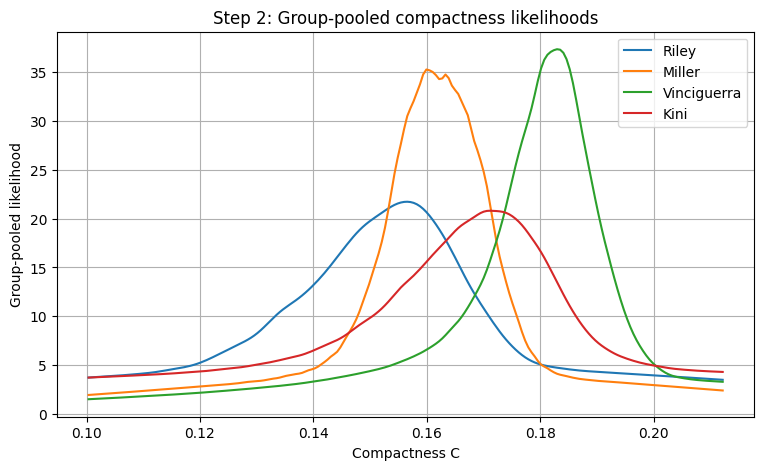

In [22]:
plt.figure(figsize=(9, 5))

s_index = len(sigma_grid) // 2
r_index = len(rho_grid) // 2

for group_name in GROUPS:
    plt.plot(
        C_grid,
        group_pool[group_name][s_index, r_index],
        label=group_name
    )

plt.xlabel("Compactness C")
plt.ylabel("Group-pooled likelihood")
plt.title("Step 2: Group-pooled compactness likelihoods")
plt.legend()
plt.grid()
plt.show()

#### form combination from groups, marginalize over parameters representing systematics

In [23]:
Ndata = len(GROUP_MODELS)
NC = len(C_grid)

# Systematic
s_C = np.std(list(C_med_group.values()))
sigma_C_sys_grid = np.linspace(0.0, 3 * s_C, 30)
prior_sigma_C_sys = normalize_pdf(norm.pdf(sigma_C_sys_grid, loc=0, scale=s_C) * 2, sigma_C_sys_grid)

# Rebuild b_dict and log_b_dict for group-level models
b_dict = build_bad_likelihoods(GROUP_MODELS, C_med_group, S_i_group, C_grid, sigma_grid, alpha_grid, prior_alpha, floor)

log_b_dict = {}
for key in GROUP_MODELS:
    log_b_dict[key] = np.log(b_dict[key] + floor)

# Precompute log probabilities (constant across sigma loop)
log_p = np.log(p_grid + floor)[None, :, None]
log_1mp = np.log(1.0 - p_grid + floor)[None, :, None]

# ------------------------------------------------------------
# 2a. First pass: build, for every sigma, the rho-independent sum
#     over models of log-mixture, and derive ONE shared numerical
#     stability constant for the whole cell.
#
#     kappa = 1/(1 + rho*(Ndata-1)) is always <= 1, so
#     kappa * sum_log_mixture <= max(sum_log_mixture, 0) everywhere.
#     That gives a single safe shift with no risk of overflow.
#
#     Using the SAME constant for every sigma, every rho, and every
#     p is what makes this purely a numerical-stability device: it
#     cancels exactly out of every normalization below, instead of
#     silently re-weighting p (the old bug) or rho/sigma (the other
#     old bug).
# ------------------------------------------------------------

sum_log_mixture_by_sigma = []

for s_index, sigma in enumerate(sigma_grid):

    log_b_stack = np.array([
        log_b_dict[key][s_index] for key in GROUP_MODELS
    ])

    log_g_exp = log_g_group_stack[:, None, :]
    log_b_exp = log_b_stack[:, None, :]

    log_mixture = logsumexp(
        np.stack([
            log_p + log_g_exp,
            log_1mp + log_b_exp
        ]),
        axis=0
    )

    sum_log_mixture_by_sigma.append(np.sum(log_mixture, axis=0))  # (len(p_grid), NC)

global_max_logL = max(0.0, max(arr.max() for arr in sum_log_mixture_by_sigma))

# ------------------------------------------------------------
# 2b. Second pass: marginalize over p, then over the systematic
#     shift kernel, keeping the UN-normalized integral as the
#     evidence for this (sigma, rho) pair.
# ------------------------------------------------------------

P_C_given_sigma_rho = np.zeros((len(sigma_grid), len(rho_grid), NC))
evidence_sigma_rho = np.zeros((len(sigma_grid), len(rho_grid)))

for s_index, sigma in enumerate(sigma_grid):

    sum_log_mixture = sum_log_mixture_by_sigma[s_index]

    for r_index, rho in enumerate(rho_grid):

        kappa = 1.0 / (1.0 + rho * (Ndata - 1))

        logL_p_C = kappa * sum_log_mixture

        # single GLOBAL shift -- not a per-row max -- so relative
        # weights between different p are preserved
        L_p_C = np.exp(logL_p_C - global_max_logL)

        L_C = np.trapz(
            L_p_C * prior_p[:, None],
            p_grid,
            axis=0
        )

        # Marginalize over the systematic-shift kernel WITHOUT
        # renormalizing each branch to unit area first -- doing
        # that would throw away the (sigma, rho)-dependent scale of
        # L_C that the evidence below depends on.
        L_C_sys = np.zeros_like(C_grid)

        for j, sigma_C_sys in enumerate(sigma_C_sys_grid):

            if np.isclose(sigma_C_sys, 0.0):
                L_conv = L_C.copy()
            else:
                L_conv = gaussian_filter1d(
                    L_C,
                    sigma=sigma_C_sys / dC,
                    mode="nearest"
                )

            L_C_sys += prior_sigma_C_sys[j] * L_conv

        # Raw integral BEFORE normalizing: this is the actual
        # evidence, proportional to p(data | sigma, rho), up to the
        # single constant exp(-global_max_logL) shared by every
        # (sigma, rho) -- which cancels in step 3 below.
        Z = np.trapz(L_C_sys, C_grid)

        P_C_given_sigma_rho[s_index, r_index] = L_C_sys / Z   # now a proper density in C
        evidence_sigma_rho[s_index, r_index] = Z              # now actually varies with sigma, rho


# ------------------------------------------------------------
# 3. Posterior over sigma and rho
# ------------------------------------------------------------

posterior_sigma_rho = (
    evidence_sigma_rho
    * prior_sigma[:, None]
    * prior_rho[None, :]
)

posterior_sigma_rho /= np.trapz(
    np.trapz(posterior_sigma_rho, rho_grid, axis=1),
    sigma_grid
)


# ------------------------------------------------------------
# 4. Final compactness posterior P(C)
# ------------------------------------------------------------

final_posterior = np.trapz(
    np.trapz(
        P_C_given_sigma_rho
        * posterior_sigma_rho[:, :, None],
        rho_grid,
        axis=1
    ),
    sigma_grid,
    axis=0
)

final_posterior = normalize_pdf(final_posterior, C_grid)


# ------------------------------------------------------------
# 5. Summary statistics
# ------------------------------------------------------------

q16, q50, q84 = get_percentiles(final_posterior, C_grid, [0.16, 0.50, 0.84])

print("\nFinal compactness constraints marginalized over p, alpha, delta, sigma, and rho:")
print(f"C = {q50:.4f}+{q84 - q50:.4f}/-{q50 - q16:.4f}")
print("16th, 50th, 84th percentiles:", [q16, q50, q84])


Final compactness constraints marginalized over p, alpha, delta, sigma, and rho:
C = 0.1683+0.0171/-0.0176
16th, 50th, 84th percentiles: [0.1507035623506458, 0.168295518198476, 0.18541048615072223]


#### plot combination against groups

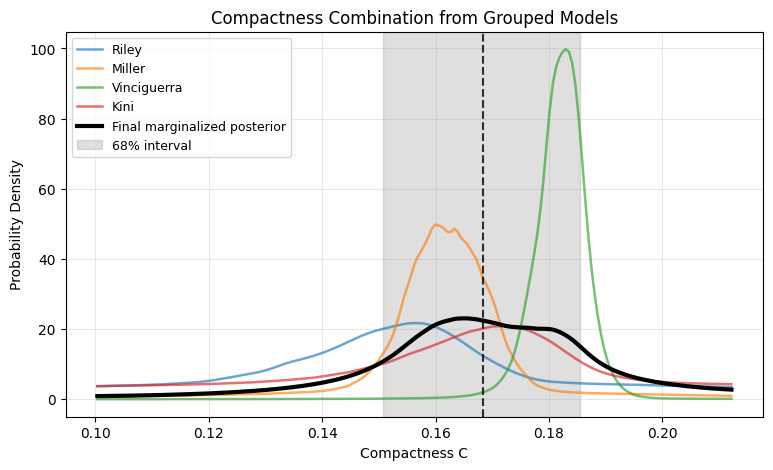

In [24]:
plt.figure(figsize=(9, 5))

group_to_idx = {g: i for i, g in enumerate(GROUP_MODELS)}

for group_name in GROUP_MODELS:
    plt.plot(
        C_grid,
        g_group_stack[group_to_idx[group_name]],
        alpha=0.65,
        linewidth=1.8,
        label=f"{group_name}"
    )

plt.plot(
    C_grid,
    final_posterior,
    color="black",
    linewidth=3,
    label="Final marginalized posterior"
)

plt.axvline(q50, color="black", linestyle="--", alpha=0.8)
plt.axvspan(q16, q84, color="gray", alpha=0.25, label="68% interval")

plt.xlabel("Compactness C")
plt.ylabel("Probability Density")
plt.title("Compactness Combination from Grouped Models")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()


#### plot marginalized parameters sigma and rho

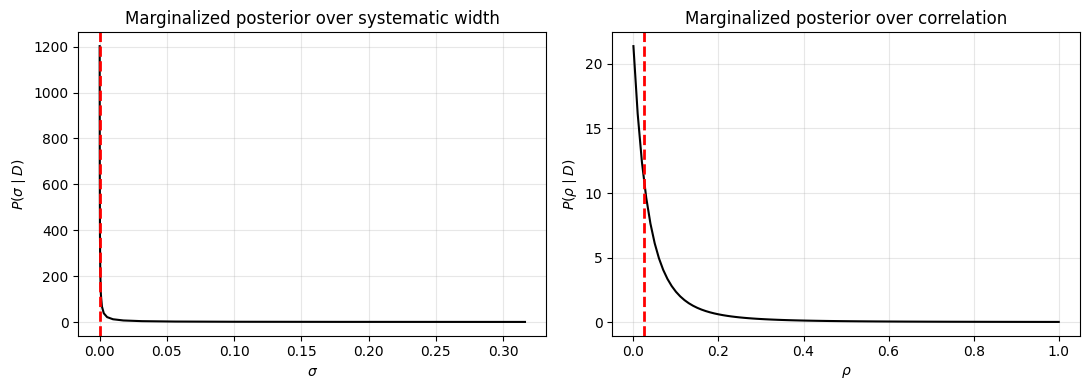

In [26]:
# ------------------------------------------------------------
# Plot posterior over rho and sigma
# ------------------------------------------------------------

posterior_sigma = np.trapz(posterior_sigma_rho, rho_grid, axis=1)
posterior_sigma /= np.trapz(posterior_sigma, sigma_grid)
med_sigma = get_percentiles(posterior_sigma, sigma_grid, [0.5])[0]

posterior_rho = np.trapz(posterior_sigma_rho, sigma_grid, axis=0)
posterior_rho /= np.trapz(posterior_rho, rho_grid)
med_rho = get_percentiles(posterior_rho, rho_grid, [0.5])[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(sigma_grid, posterior_sigma, color="black")
axes[0].axvline(med_sigma, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel(r"$\sigma$")
axes[0].set_ylabel(r"$P(\sigma \mid D)$")
axes[0].set_title("Marginalized posterior over systematic width")
axes[0].grid(alpha=0.3)

axes[1].plot(rho_grid, posterior_rho, color="black")
axes[1].axvline(med_rho, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel(r"$\rho$")
axes[1].set_ylabel(r"$P(\rho \mid D)$")
axes[1].set_title("Marginalized posterior over correlation")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()